# Assignment 1: Customer Type Classification

'''Predict `CustomerType` from transaction data using:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

This notebook loads `ecommerce_bigdata.csv` (same folder), preprocesses features, trains the three models, and compares their performance.
'''

In [24]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

In [25]:
# Load data (file must be in the same folder as this notebook)
df = pd.read_csv('ecommerce_bigdata.csv', parse_dates=['Date'])
df.head()

,TransactionID,Date,Region,ProductCategory,CustomerType,Sales,Profit
0,TX0001,2026-06-16,Eastern,Electronics,Wholesale,4924,359.44
1,TX0002,2026-02-12,Central,Electronics,Retail,3283,944.32
2,TX0003,2026-03-01,Northern,Food,Online,4049,967.10
3,TX0004,2026-06-03,Western,Household Products,Online,4331,434.57
4,TX0005,2026-01-21,Western,Household Products,Retail,3283,340.48


In [26]:
# Basic preprocessing
# Extract month from Date and select useful features
df['Month'] = df['Date'].dt.month
X = df[[ 'Region', 'ProductCategory', 'Sales', 'Profit', 'Month' ]]
y = df['CustomerType']
X.shape, y.shape

((200, 5), (200,))

In [27]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((160, 5), (40, 5))

In [28]:
# Preprocessor: scale numeric, one-hot encode categorical
cat_features = ['Region', 'ProductCategory']
num_features = ['Sales', 'Profit', 'Month']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ]
)

In [29]:
# Helper to train and evaluate a pipeline with a classifier
def train_eval(clf, name):
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f'--- {name} ---')
    print('Accuracy:', round(acc,4))
    print('Classification report:\n')
    print(classification_report(y_test, preds))
    # Aggregate metrics: macro and weighted
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    print('Aggregate metrics:')
    print(f'  Macro Precision: {macro_p:.4f}  Macro Recall: {macro_r:.4f}  Macro F1: {macro_f1:.4f}')
    print(f'  Weighted Precision: {weighted_p:.4f}  Weighted Recall: {weighted_r:.4f}  Weighted F1: {weighted_f1:.4f}')
    # Per-class precision/recall/f1
    classes = np.unique(np.concatenate([y_train.unique(), y_test.unique()]))
    p, r, f1, s = precision_recall_fscore_support(y_test, preds, labels=classes, zero_division=0)
    metrics_df = pd.DataFrame({'precision': p, 'recall': r, 'f1': f1, 'support': s}, index=classes)
    print('Per-class metrics:')
    print(metrics_df)
    # Confusion matrix (counts)
    cm = confusion_matrix(y_test, preds, labels=classes)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - {name} (counts)')
    plt.show()
    # Normalized confusion matrix (by true labels)
    cm_norm = confusion_matrix(y_test, preds, labels=classes, normalize='true')
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - {name} (normalized)')
    plt.show()
    return acc, pipe

--- Logistic Regression ---
Accuracy: 0.325
Classification report:

              precision    recall  f1-score   support

      Online       0.25      0.17      0.20        12
      Retail       0.14      0.08      0.11        12
   Wholesale       0.40      0.62      0.49        16

    accuracy                           0.33        40
   macro avg       0.26      0.29      0.26        40
weighted avg       0.28      0.33      0.29        40

Aggregate metrics:
  Macro Precision: 0.2643  Macro Recall: 0.2917  Macro F1: 0.2644
  Weighted Precision: 0.2779  Weighted Recall: 0.3250  Weighted F1: 0.2867
Per-class metrics:
           precision    recall        f1  support
Online      0.250000  0.166667  0.200000       12
Retail      0.142857  0.083333  0.105263       12
Wholesale   0.400000  0.625000  0.487805       16


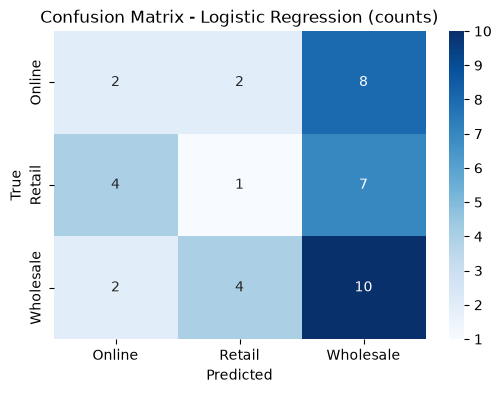

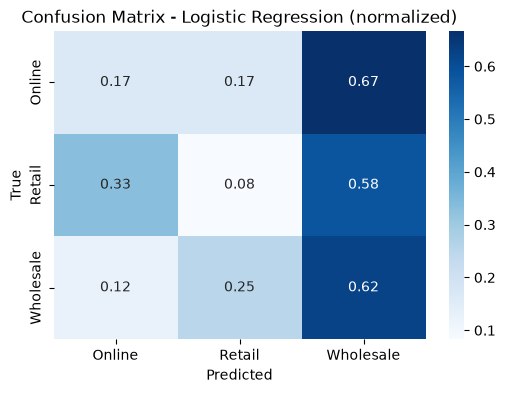

In [31]:
# Logistic Regression
log_clf = LogisticRegression(max_iter=1000)
log_acc, log_pipe = train_eval(log_clf, 'Logistic Regression')

--- Decision Tree ---
Accuracy: 0.375
Classification report:

              precision    recall  f1-score   support

      Online       0.40      0.50      0.44        12
      Retail       0.33      0.33      0.33        12
   Wholesale       0.38      0.31      0.34        16

    accuracy                           0.38        40
   macro avg       0.37      0.38      0.37        40
weighted avg       0.37      0.38      0.37        40

Aggregate metrics:
  Macro Precision: 0.3726  Macro Recall: 0.3819  Macro F1: 0.3742
  Weighted Precision: 0.3738  Weighted Recall: 0.3750  Weighted F1: 0.3713
Per-class metrics:
           precision    recall        f1  support
Online      0.400000  0.500000  0.444444       12
Retail      0.333333  0.333333  0.333333       12
Wholesale   0.384615  0.312500  0.344828       16


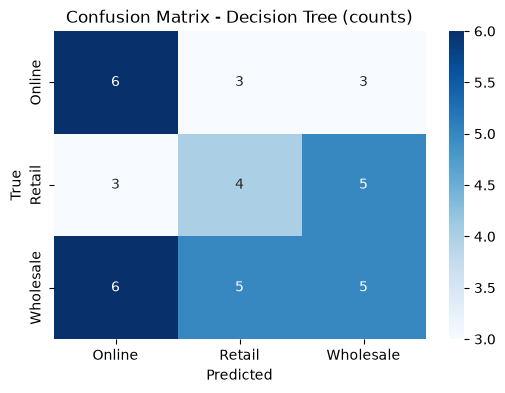

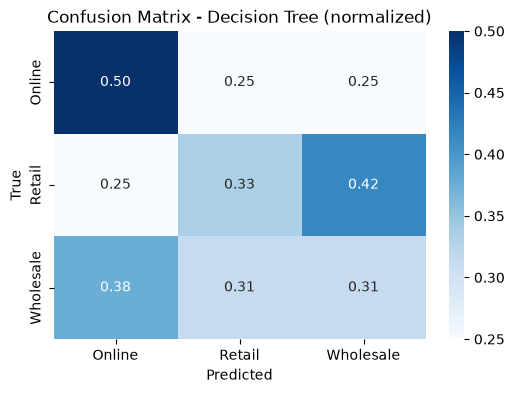

In [32]:
# Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_acc, dt_pipe = train_eval(dt_clf, 'Decision Tree')

--- Random Forest ---
Accuracy: 0.325
Classification report:

              precision    recall  f1-score   support

      Online       0.25      0.25      0.25        12
      Retail       0.43      0.25      0.32        12
   Wholesale       0.33      0.44      0.38        16

    accuracy                           0.33        40
   macro avg       0.34      0.31      0.31        40
weighted avg       0.34      0.33      0.32        40

Aggregate metrics:
  Macro Precision: 0.3373  Macro Recall: 0.3125  Macro F1: 0.3147
  Weighted Precision: 0.3369  Weighted Recall: 0.3250  Weighted F1: 0.3211
Per-class metrics:
           precision  recall        f1  support
Online      0.250000  0.2500  0.250000       12
Retail      0.428571  0.2500  0.315789       12
Wholesale   0.333333  0.4375  0.378378       16


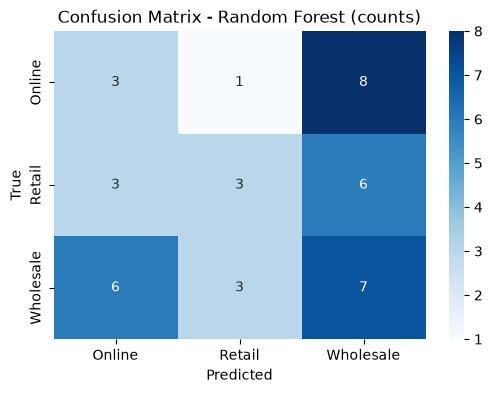

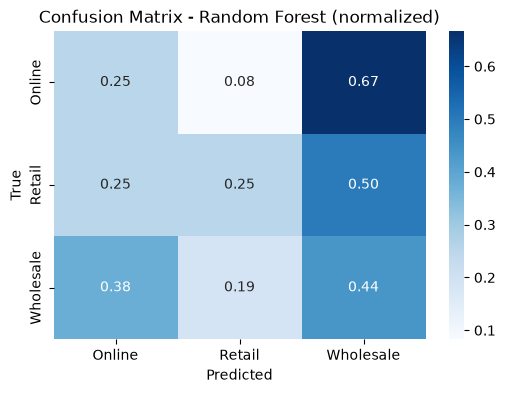

In [33]:
# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc, rf_pipe = train_eval(rf_clf, 'Random Forest')

In [34]:
# Summary comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy': [log_acc, dt_acc, rf_acc]
})
results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

,Model,Accuracy
0,Decision Tree,0.375
1,Logistic Regression,0.325
2,Random Forest,0.325
